# Playground Series S6E8 — Smartphone Addiction

Binary classification: predict `addicted_label`. `sample_submission.csv` holds probabilities,
so the metric is almost certainly ROC AUC — submit probabilities, not hard labels.

This notebook is the initial data description / EDA pass.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

DATA = "data"
train = pd.read_csv(f"{DATA}/train.csv")
test = pd.read_csv(f"{DATA}/test.csv")
sample_sub = pd.read_csv(f"{DATA}/sample_submission.csv")

TARGET = "addicted_label"
train.shape, test.shape, sample_sub.shape

((691369, 14), (296302, 13), (296302, 2))

## Schema and first rows

In [2]:
train.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  str    
 11  stress_level             636221 non-null  str    
 12  academic_work_impact     647145 non-null  str    
 13  addicted_label           691369 non-null  int64  
dtypes: float64(9), 

## Column groups

In [4]:
num_cols = [c for c in train.select_dtypes(include=np.number).columns if c not in ("id", TARGET)]
cat_cols = [c for c in train.columns if train[c].dtype == object]

print("numeric  :", num_cols)
print("categoric:", cat_cols)
print("test has same columns minus target:", set(train.columns) - set(test.columns))

numeric  : ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
categoric: []
test has same columns minus target: {'addicted_label'}


## Target balance

addicted_label
0    200895
1    490474
Name: count, dtype: int64
addicted_label
0    0.290576
1    0.709424
Name: proportion, dtype: float64


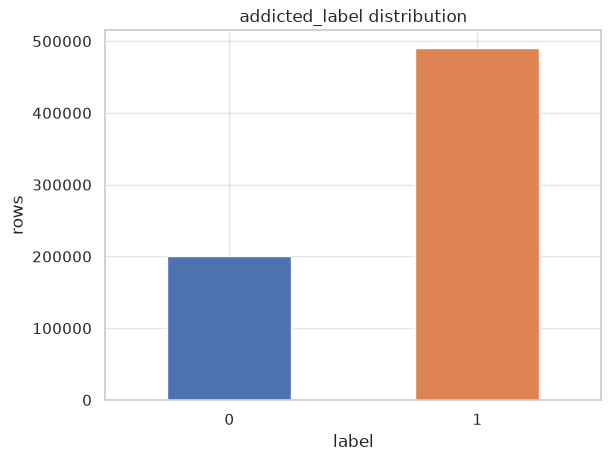

In [5]:
counts = train[TARGET].value_counts().sort_index()
print(counts)
print(train[TARGET].value_counts(normalize=True).sort_index())

ax = counts.plot(kind="bar", color=["#4c72b0", "#dd8452"], rot=0)
ax.set_title("addicted_label distribution")
ax.set_xlabel("label"); ax.set_ylabel("rows")
plt.show()

## Missing values

Every feature has missing values in both train and test — this is a synthetic Playground
dataset where NaNs were injected on purpose. Tree models (LightGBM / XGBoost / CatBoost)
handle them natively; if you impute, add `_isna` indicator columns, since missingness
itself may carry signal.

In [6]:
miss = pd.DataFrame({
    "train_n": train.isna().sum(),
    "train_pct": train.isna().mean().mul(100).round(2),
    "test_pct": test.isna().mean().mul(100).round(2),
})
miss = miss[miss.train_n > 0].sort_values("train_pct", ascending=False)
miss

,train_n,train_pct,test_pct
social_media_hours,133995,19.38,16.00
gaming_hours,126821,18.34,20.05
weekend_screen_time,112063,16.21,17.11
daily_screen_time_hours,95854,13.86,11.07
app_opens_per_day,80710,11.67,8.68
notifications_per_day,67584,9.78,11.55
stress_level,55148,7.98,6.62
work_study_hours,51518,7.45,9.37
sleep_hours,44480,6.43,7.58
academic_work_impact,44224,6.40,8.68


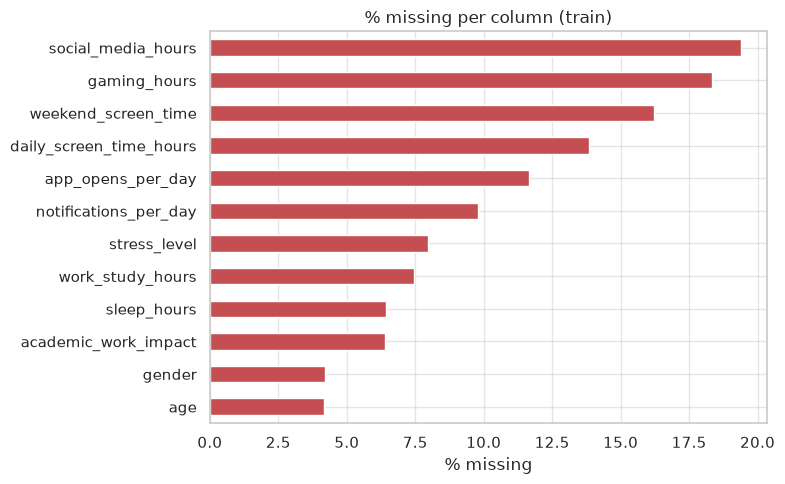

In [7]:
ax = miss["train_pct"].sort_values().plot(kind="barh", figsize=(8, 5), color="#c44e52")
ax.set_title("% missing per column (train)")
ax.set_xlabel("% missing")
plt.tight_layout(); plt.show()

In [8]:
# does missingness itself predict the target?
pd.DataFrame({
    c: train.groupby(train[c].isna())[TARGET].mean()
    for c in miss.index
}).T.rename(columns={False: "rate_present", True: "rate_missing"}).round(4)

,rate_present,rate_missing
social_media_hours,0.7094,0.7094
gaming_hours,0.7092,0.7105
weekend_screen_time,0.7092,0.7107
daily_screen_time_hours,0.7091,0.7113
app_opens_per_day,0.7090,0.7128
notifications_per_day,0.7093,0.7102
stress_level,0.7095,0.7090
work_study_hours,0.7093,0.7106
sleep_hours,0.7092,0.7134
academic_work_impact,0.7094,0.7095


## Numeric features — describe

In [9]:
train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


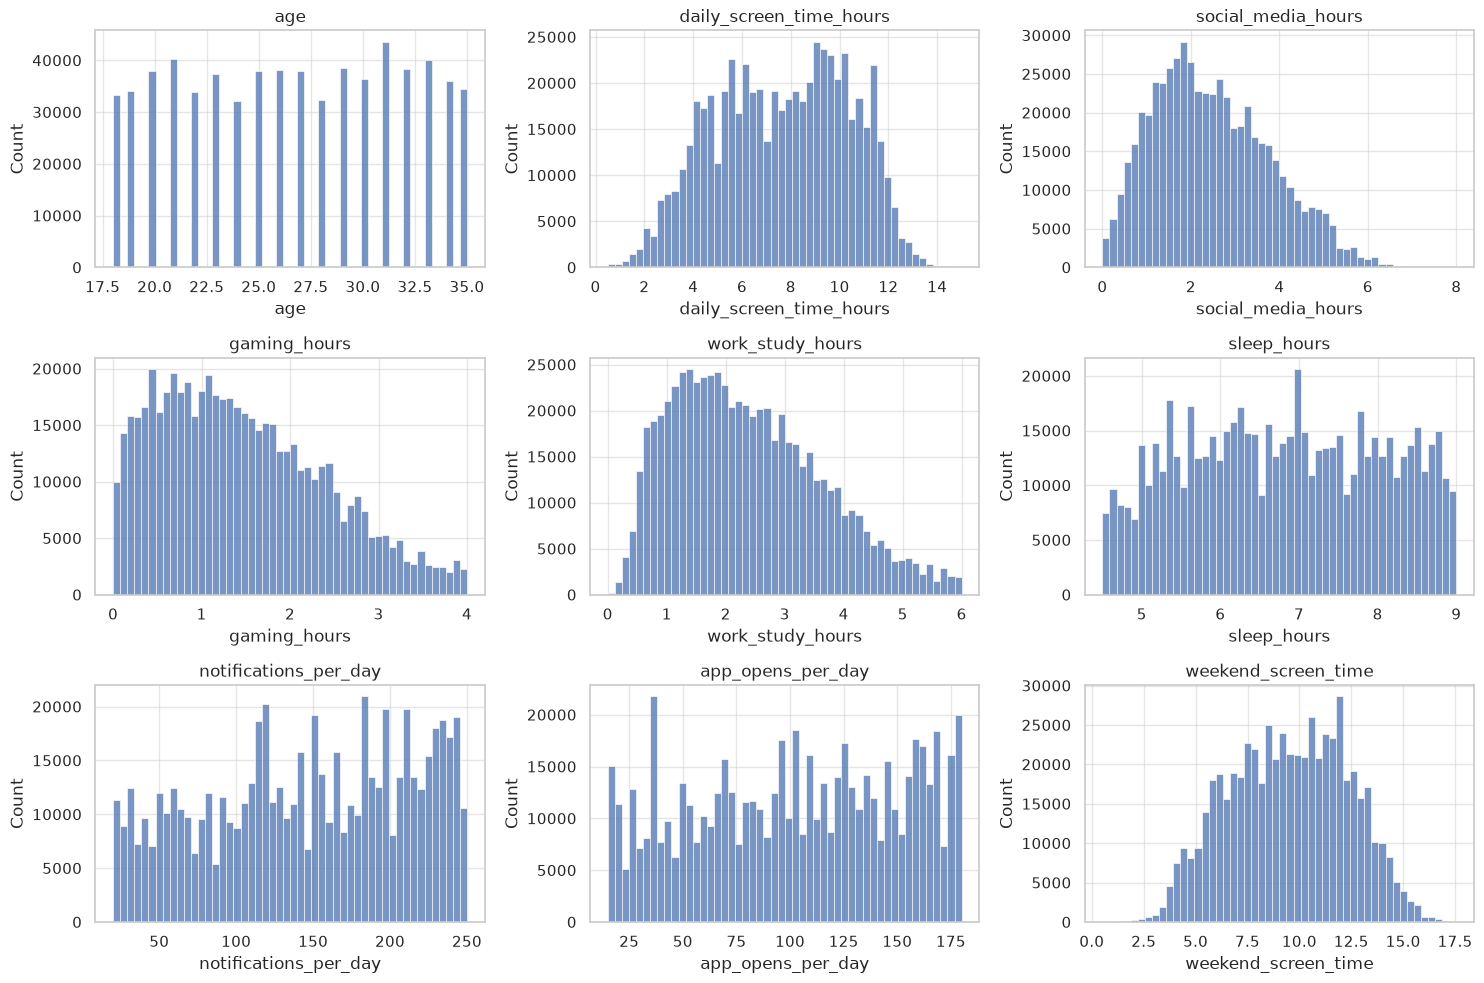

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(train[c].dropna(), bins=50, ax=ax, color="#4c72b0")
    ax.set_title(c)
for ax in axes.ravel()[len(num_cols):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

### Numeric features split by target

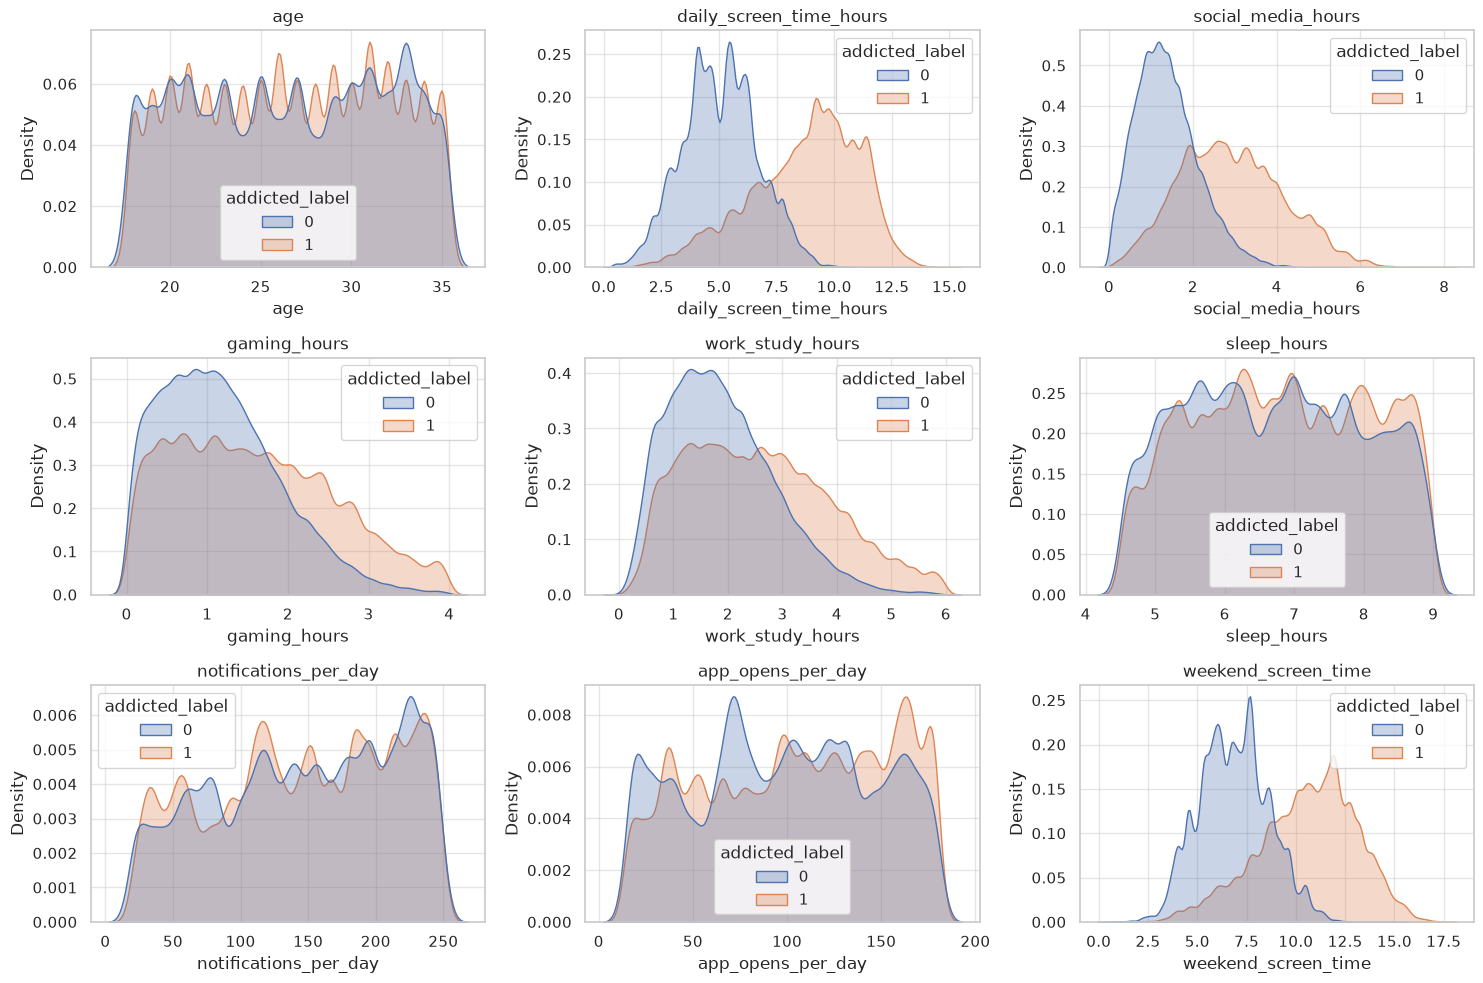

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, c in zip(axes.ravel(), num_cols):
    sns.kdeplot(data=train, x=c, hue=TARGET, common_norm=False, ax=ax, fill=True, alpha=.3)
    ax.set_title(c)
for ax in axes.ravel()[len(num_cols):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## Categorical features

In [12]:
for c in cat_cols:
    print(c)
    print(train[c].value_counts(dropna=False))
    print(train.groupby(c, dropna=False)[TARGET].agg(["mean", "size"]).round(4))
    print("-" * 60)

## Correlations

`daily_screen_time_hours`, `weekend_screen_time` and `social_media_hours` are the dominant
signals. `age` and `notifications_per_day` are essentially uncorrelated with the target on
their own.

In [13]:
corr = train[num_cols + [TARGET]].corr()
corr[TARGET].drop(TARGET).sort_values(ascending=False)

daily_screen_time_hours    0.611398
weekend_screen_time        0.589903
social_media_hours         0.532409
work_study_hours           0.251416
gaming_hours               0.205283
app_opens_per_day          0.063482
sleep_hours                0.042545
age                        0.004043
notifications_per_day     -0.011583
Name: addicted_label, dtype: float64

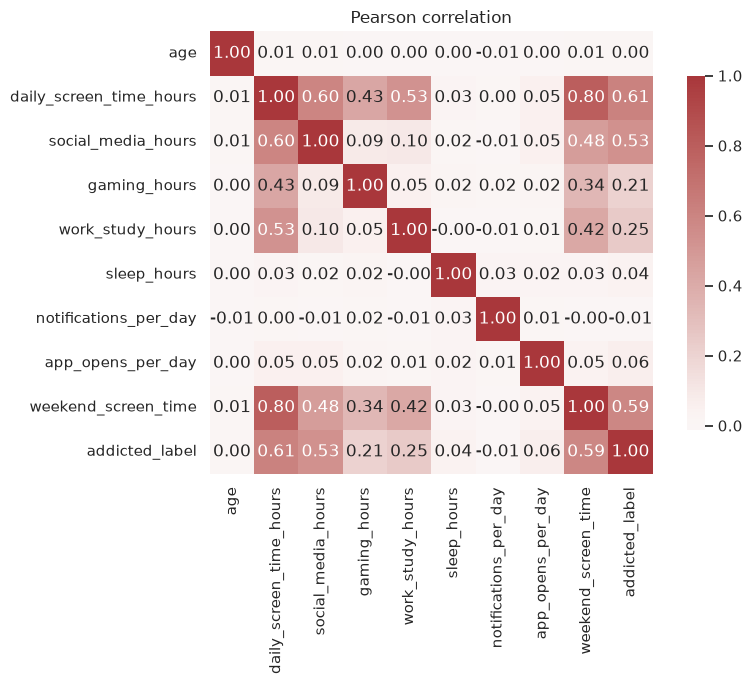

In [14]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, cbar_kws={"shrink": .8})
plt.title("Pearson correlation")
plt.tight_layout(); plt.show()

## Train vs test distribution check

Playground train/test are usually drawn from the same generator; confirm before trusting CV.

In [15]:
pd.DataFrame({
    "train_mean": train[num_cols].mean(),
    "test_mean": test[num_cols].mean(),
    "train_std": train[num_cols].std(),
    "test_std": test[num_cols].std(),
}).round(3)

,train_mean,test_mean,train_std,test_std
age,26.615,26.609,5.153,5.153
daily_screen_time_hours,7.641,7.641,2.721,2.726
social_media_hours,2.471,2.471,1.316,1.318
gaming_hours,1.459,1.458,0.935,0.935
work_study_hours,2.367,2.366,1.259,1.257
sleep_hours,6.804,6.802,1.235,1.236
notifications_per_day,145.895,145.748,65.918,66.015
app_opens_per_day,102.637,102.656,48.094,48.186
weekend_screen_time,9.480,9.475,2.856,2.858


## Sanity checks

In [16]:
print("duplicate rows (ignoring id):", train.drop(columns="id").duplicated().sum())
print("id unique in train:", train.id.is_unique, "| in test:", test.id.is_unique)
print("id ranges — train:", (train.id.min(), train.id.max()), "test:", (test.id.min(), test.id.max()))
print("test ids match submission ids:", test.id.equals(sample_sub.id))

duplicate rows (ignoring id): 0
id unique in train: True | in test: True
id ranges — train: (0, 691368) test: (691369, 987670)
test ids match submission ids: True


## Takeaways

- ~691k train rows, ~296k test rows, 12 features + `id` + target.
- Target is imbalanced ~71% / 29% positive — use stratified CV, evaluate with AUC.
  Do **not** use class weighting or resampling: the imbalance is mild and AUC is
  rank-based, so it does not help.
- Every column has 4-19% missing values in both splits. Tested: the missingness
  indicator for every column scores AUC 0.50 +/- 0.005, i.e. the NaNs are MCAR and
  carry no signal. **Do not add `_isna` indicator columns** - use a model with
  native NaN support and leave the gaps alone.
- Screen-time features (`daily_screen_time_hours`, `weekend_screen_time`,
  `social_media_hours`) carry most of the linear signal; `age` and
  `notifications_per_day` carry almost none on their own.
- Structural constraint: `daily_screen_time_hours >= social_media_hours +
  gaming_hours + work_study_hours`, with 0 violations across the 421,427 rows where
  all four are present. The three activity columns are slices of the daily total,
  and the leftover is unlabeled screen time (mean 1.34h). Useful for bounded
  imputation if imputation is ever needed.
- `weekend_screen_time / daily_screen_time_hours` is *inversely* related to the
  target - heavy users are already saturated on weekdays and have no room to spike.
- All three categorical columns are low-cardinality (2-3 levels) - one-hot is fine.

### Model family comparison (200k subsample, single 80/20 split)

| model | raw features | + engineered features |
|---|---|---|
| LogisticRegression | 0.9100 | 0.9176 |
| MLP (64, 32) | 0.9327 | 0.9333 |
| HistGradientBoosting | **0.9519** | **0.9527** |

Boosted trees win decisively. Note that hand-built interaction features
(`screen x social`, `screen / awake_hours`, the residual, etc.) add +0.008 to a
linear model but only +0.0008 to a tree - the tree already finds those
interactions itself. Single-feature AUCs made those features look valuable
(`screen x social` scores 0.900 alone), but that value is only realisable by a
model that cannot construct interactions on its own.

**Conclusion: skip hand-built ratio/product features. Spend the effort on tuning
and ensembling boosted trees instead.**

Next: `02_baseline.ipynb` - LightGBM with stratified K-fold, AUC scoring.